In [33]:
from optimal.RobotMujocoModel import RobotMujocoModel
from optimal.RobotPinocchioModel import RobotPinocchioModel
from optimal.RobotController import RobotController
from optimal.configuration import UR10
import optimal.metrics as metrics
import numpy as np
type = UR10
robot_mj_model = RobotMujocoModel(type.mjcf_path, type.list_of_joints)
robot_pin_model = RobotPinocchioModel(type.urdf_path, type.list_of_joints)

def objective(trial, DT, start, target):
    # Ask Optuna to guess the weights (we use log scale because weights can vary wildly)
    track_weight          = trial.suggest_float("track_weight",          1e-5, 1e5,  log=True)
    ctrl_weight           = trial.suggest_float("ctrl_weight",           1e-1, 1e5,  log=True)
    terminal_pose_weight  = trial.suggest_float("terminal_pose_weight",  1e3,  1e7,  log=True)
    v_weight              = trial.suggest_float("v_weight",              1e2,  1e5,  log=True)
    acc_weight            = trial.suggest_float("acc_weight",            1e2,  1e7,  log=True)
    
    # Initialize your controller
    controller = RobotController(robot_pin_model)
    xs, us = [], []    
    try:
        for start, target in zip(start, target):
            t_xs, t_us = controller.compute_control(q_start=start, 
                                                q_target=target, 
                                                T=1000, DT=DT, kp=type.kp, kd=type.kd,
                                                track_weight=track_weight, 
                                                ctrl_weight=ctrl_weight, 
                                                terminal__pose_weight=terminal_pose_weight,
                                                v_weight=v_weight,
                                                acc_weight=acc_weight,
                                                option="crocoddyl_advanced")
            xs.append(t_xs)
            us.append(t_us)
    except Exception as e:
        # If the solver crashes (e.g. weights were numerically unstable), 
        # return a massive penalty so Optuna knows it was a bad guess.
        return float('inf')

    # --- 3. Evaluate the Metric (How good was the result?) ---
    
    # A. Terminal Error (Distance from final position to target)
    terminal_error = metrics.terminal_error(xs[-1][:robot_pin_model.model.nq], target)
    
    # B. Control Effort (Sum of squared torques)
    control_effort = metrics.thermal_energy(us, DT)
    
    # C. Smoothness (Sum of squared changes in torque)
    torque_jerk = metrics.torque_jerk(us)

    mechanical_work = metrics.mechanical_work(us, xs, DT)
    peak_power = metrics.peak_power(us, xs, DT)
    
    # Combine into a single score. 
    # Notice we weigh terminal error heavily because missing the target is a failure.
    metric_score = (1e5 * terminal_error) + (.5 * control_effort) + (.5 * torque_jerk) + (.5 * mechanical_work) + (.5 * peak_power)
    
    return metric_score

In [34]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

DT = robot_mj_model.model.opt.timestep
path = [robot_pin_model.current_q(),
     np.array([-1.8, -1.8, 1.8, -1.8, -1.8, 1.8]),
     np.array([-1.8, -1.2, 1.5, -1.8, -1.8, 1.8]),
     np.array([-1.8, -1.8, 1.8, -1.8, -1.8, 1.8]),
     np.array([0.4, -0.4, 1.5, -0.8, 1.5, 0.5])]

params = []
start = path[:-1]
target = path[1:]
study = optuna.create_study(direction="minimize")
study.optimize(lambda trial: objective(trial, DT, start, target), n_trials=1000, show_progress_bar=True)
print("Best parameters:", study.best_params)
params = [study.best_params for _ in range(len(start))]

Best trial: 0. Best value: inf: 100%|██████████| 1000/1000 [00:14<00:00, 67.55it/s]

Best parameters: {'track_weight': 7.643309002333162e-05, 'ctrl_weight': 4518.042924054273, 'terminal_pose_weight': 87630.2727238351, 'v_weight': 31074.388782899758, 'acc_weight': 7508.850315955597}


In [7]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

DT = robot_mj_model.model.opt.timestep
path = [robot_pin_model.current_q(),
     np.array([-1.8, -1.8, 1.8, -1.8, -1.8, 1.8]),
     np.array([-1.8, -1.2, 1.5, -1.8, -1.8, 1.8]),
     np.array([-1.8, -1.8, 1.8, -1.8, -1.8, 1.8]),
     np.array([0.4, -0.4, 1.5, -0.8, 1.5, 0.5])]

params = []
for i in range(len(path)):
    print(f"--- Evaluating Path {i+1}/{len(path)} ---")
    # Create the study. We want to MINIMIZE the metric_score.
    study = optuna.create_study(direction="minimize")

    # Run 100 trials (guesses)
    print("Starting Optuna search...")
    func = lambda trial: objective(trial, DT, path[i-1], path[i])
    study.optimize(func, n_trials=100, show_progress_bar=True)
    
    params.append(study.best_params)
print("\n=== All Best Coefficients ===")
for i, param in enumerate(params):
    print(f"Path {i+1}: {param}")

--- Evaluating Path 1/5 ---
Starting Optuna search...


Best trial: 0. Best value: inf: 100%|██████████| 100/100 [00:00<00:00, 146.80it/s]


--- Evaluating Path 2/5 ---
Starting Optuna search...


Best trial: 0. Best value: inf: 100%|██████████| 100/100 [00:00<00:00, 169.57it/s]


--- Evaluating Path 3/5 ---
Starting Optuna search...


...

--- Evaluating Path 4/5 ---
Starting Optuna search...


Best trial: 0. Best value: inf: 100%|██████████| 100/100 [00:00<00:00, 151.95it/s]


--- Evaluating Path 5/5 ---
Starting Optuna search...


Best trial: 0. Best value: inf: 100%|██████████| 100/100 [00:00<00:00, 167.85it/s]


=== All Best Coefficients ===
Path 1: {'track_weight': 17136.383019411038, 'ctrl_weight': 41415.4868553629, 'terminal_pose_weight': 919192.1536874652, 'v_weight': 6333761.053728829, 'acc_weight': 4618476.528456467}
Path 2: {'track_weight': 44077.21745217071, 'ctrl_weight': 50631.16326422329, 'terminal_pose_weight': 2914833.503136138, 'v_weight': 8547075.320390835, 'acc_weight': 7900882.500196844}
Path 3: {'track_weight': 63626.13510461461, 'ctrl_weight': 49116.11313576433, 'terminal_pose_weight': 6435423.3171876315, 'v_weight': 9453036.230227398, 'acc_weight': 2578942.0881164744}
Path 4: {'track_weight': 68579.41460578592, 'ctrl_weight': 67410.21113814597, 'terminal_pose_weight': 1620067.2996074033, 'v_weight': 4284882.193126454, 'acc_weight': 5777601.730575915}
Path 5: {'track_weight': 18005.3858448006, 'ctrl_weight': 12377.951329343967, 'terminal_pose_weight': 8217469.008841279, 'v_weight': 5270556.3671350945, 'acc_weight': 6445170.604092841}


No warm start provided; computing warm start using PD control.
No warm start provided; computing warm start using PD control.
No warm start provided; computing warm start using PD control.
No warm start provided; computing warm start using PD control.


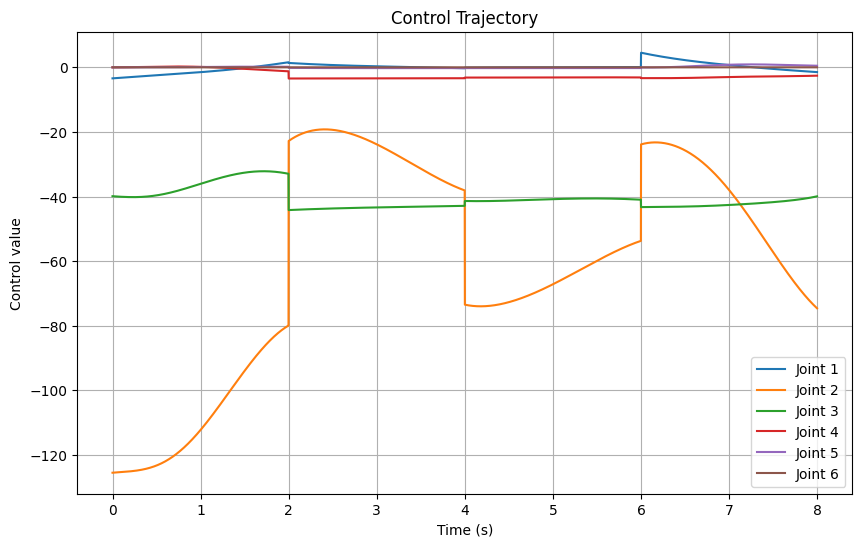

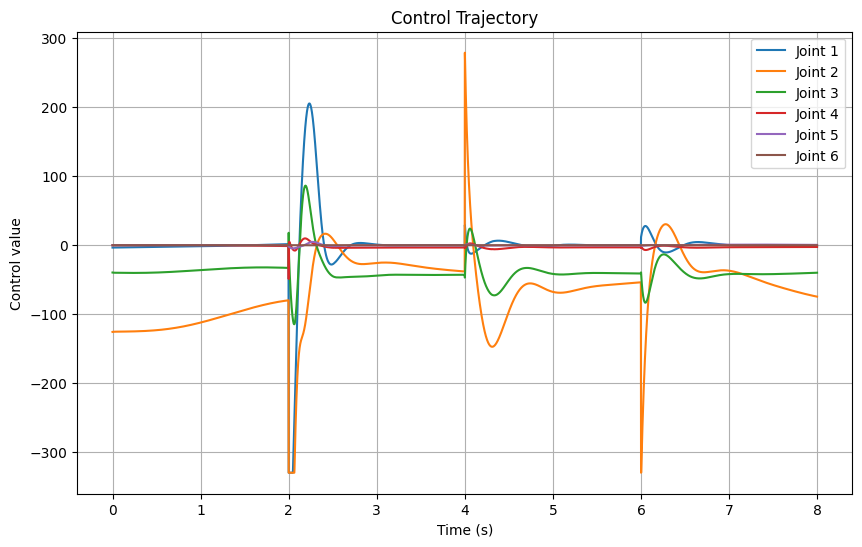

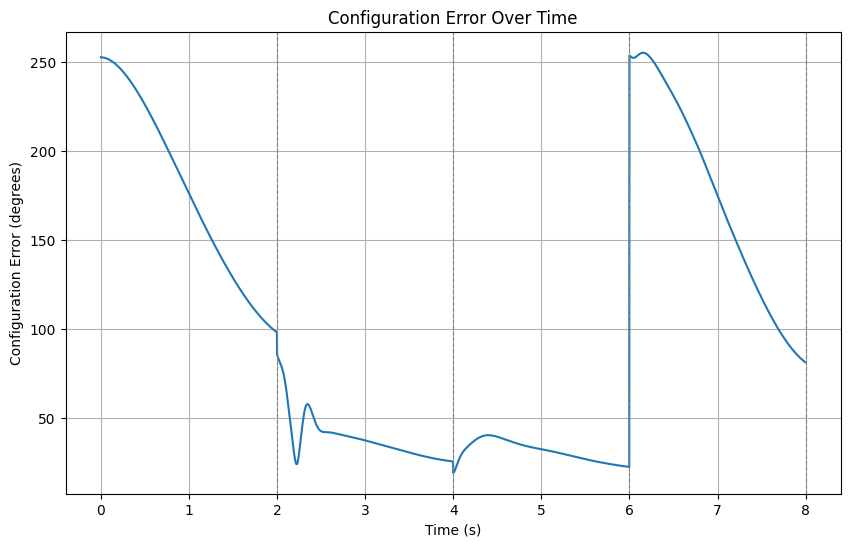

In [35]:
from optimal.RobotController import RobotController
from optimal.RobotMujocoModel import RobotMujocoModel
from optimal.RobotPinocchioModel import RobotPinocchioModel
from optimal.configuration import UR10, UR10_sandbox
from optimal.metrics import thermal_energy, mechanical_work, peak_power
import numpy as np

type = UR10_sandbox
robot_mj_model = RobotMujocoModel(type.mjcf_path, type.list_of_joints)
robot_pin_model = RobotPinocchioModel(type.urdf_path, type.list_of_joints)

DT = robot_mj_model.model.opt.timestep
path = [robot_pin_model.current_q(),
     np.array([-1.8, -1.8, 1.8, -1.8, -1.8, 1.8]),
     np.array([-1.8, -1.2, 1.5, -1.8, -1.8, 1.8]),
     np.array([-1.8, -1.8, 1.8, -1.8, -1.8, 1.8]),
     np.array([0.4, -0.4, 1.5, -0.8, 1.5, 0.5])]
controller = RobotController(robot_pin_model)
xs, us = [], []
v_start = np.zeros(len(robot_pin_model.v_indices))
for i in range(len(path) - 1):
    start = np.concatenate([path[i], v_start])
    target = np.concatenate([path[i+1], np.zeros(len(robot_pin_model.v_indices))])
    t_xs, t_us = controller.compute_control(x_start=start, 
                                        x_goal=target, 
                                        T=1000, DT=DT, kp=type.kp, kd=type.kd,
                                        option="crocoddyl_advanced", 
                                        track_weight=params[i]['track_weight'], 
                                        ctrl_weight=params[i]['ctrl_weight'], 
                                        terminal_pose_weight=params[i]['terminal_pose_weight'],
                                        v_weight=params[i]['v_weight'],
                                        acc_weight=params[i]['acc_weight'])
    xs.extend(t_xs)
    us.extend(t_us)
    v_start = xs[-1][len(robot_pin_model.q_indices):]  # Update v_start for the next segment

# xs_real, us_real = robot_mj_model.visualize("control", us=us, dt=DT, hold=False)
# robot_mj_model.plot_error(xs_real, path[1:], segment_lengths=[1000]*len(path), dt=DT)
# robot_mj_model.reset()
xs_real, us_real = robot_mj_model.visualize("control", us=us, xs=xs, kp=type.kp, kd=type.kd, dt=DT, hold=False)
# xs_real, us_real = robot_mj_model.visualize("control", us=us, dt=DT, hold=False)
robot_mj_model.plot_controls(us, dt=DT)
robot_mj_model.plot_controls(us_real, dt=DT)
robot_mj_model.plot_error(xs_real, path[1:], segment_lengths=[1000]*len(path), dt=DT)

In [ ]:
xs_real, us_real = robot_mj_model.visualize("position", xs=xs, dt=DT, hold=False)


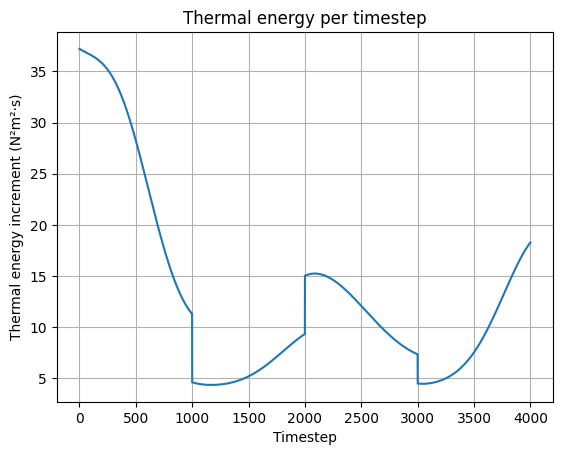

Thermal energy: 53244.02609614903


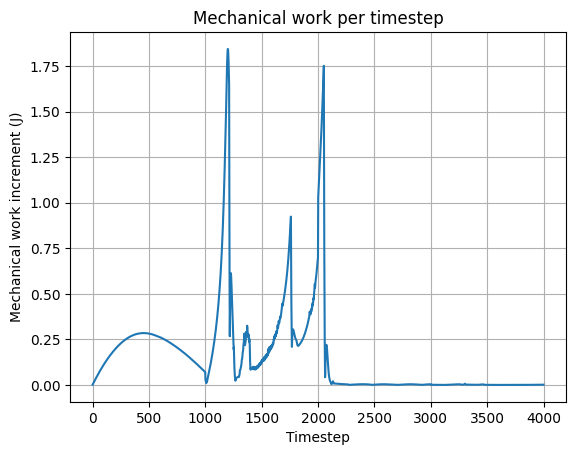

Mechanical work: 635.965011804241


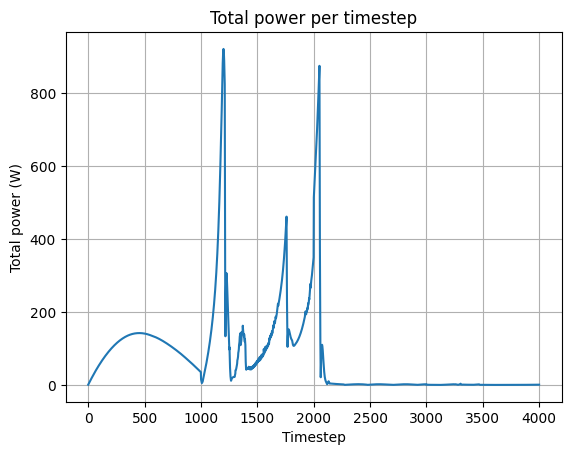

Peak power: 921.7674161942483


In [22]:
E_th  = thermal_energy(us_real, DT, True)
print("Thermal energy:", E_th)
E_mech = mechanical_work(us_real, xs_real, DT, True)
print("Mechanical work:", E_mech)
P_peak = peak_power(us_real, xs_real, True)
print("Peak power:", P_peak)